## **Testes e Análises dos Dados de Medidores**

Esse notebook visa realizar testes e análises para o desenvolvimento do problema envolvendo as imagens dos medidores tirados pelos leituristas da Neroenergia.

- Configurações iniciais

In [2]:
# Bibliotecas
import pandas as pd
import numpy as np
import cv2
import matplotlib.pyplot as plt
import glob
import os

# Pandas configs
pd.set_option("display.max_columns", None)
pd.set_option('display.max_colwidth', None)

- Dicionário de Dados | Bases CSVs

| Coluna | Tipo | Descrição | Exemplo |
|---|---|---|---|
| **Numero do medidor** | Texto | Identificador numérico do medidor ao qual o registro pertence. | `3213492267` |
| **Posicao do medidor lida** | Inteiro | Valor da leitura registrada para o medidor no momento da coleta. | `6521` |
| **Nota de Leitura Atual** | Texto | Código ou observação associada à leitura atual. Pode apresentar valor nulo quando não há uma nota registrada. | `L131` |
| **Foto do medidor** | Texto | Nome do arquivo da fotografia correspondente ao registro do medidor. | `PSP_EXTRATLEITIMPL_030726_0121_20000000012852988478_000.jpg` |

- **Tópico 1 -** Análise dos arquivos `CSVs`

In [3]:
# Analisando estrutura dos dados CSVs
sheets = glob.glob('../data/sheets/*.csv')
df = pd.concat([pd.read_csv(sheet, sep=';') for sheet in sheets])

display(df.head())
df.info()

,Numero do medidor,Posicao do medidor lida,Nota de Leitura Atual,Foto do medidor
0,3213492267,6521,NaN,PSP_EXTRATLEITIMPL_030726_0121_20000000012852988478_000.jpg
1,40482962,9729,L131,PSP_EXTRATLEITIMPL_030726_0121_20000000003053017019_000.jpg
2,30501853,24788,NaN,PSP_EXTRATLEITIMPL_030726_0121_20000000006502995976_000.jpg
3,82861661,20512,NaN,PSP_EXTRATLEITIMPL_030726_0121_20000000012552976989_000.jpg
4,3221134515,1698,NaN,PSP_EXTRATLEITIMPL_030726_0121_20000000017102988986_000.jpg


<class 'pandas.core.frame.DataFrame'>
Index: 13669 entries, 0 to 3259
Data columns (total 4 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Numero do medidor        13669 non-null  object
 1   Posicao do medidor lida  13669 non-null  int64 
 2   Nota de Leitura Atual    4560 non-null   object
 3   Foto do medidor          11474 non-null  object
dtypes: int64(1), object(3)
memory usage: 533.9+ KB


Após análise inicial dos dados, é possível ver que as colunas `Numero do medidor` e `Posicao do medidor lida` estão todas preenchidas. Já as demais colunas estão com uma boa quantidade de valores nulos. O próximo passo é identificar mais detalhadamente esses valores.

In [53]:
# Verificando colunas com valores nulos
print("Verificação de valores nulos [Nota de Leitura Atual]:", df["Nota de Leitura Atual"].isnull().sum())
print("Verificação de valores nulos [Foto do medidor]:", df["Foto do medidor"].isnull().sum())

Verificação de valores nulos [Nota de Leitura Atual]: 9109
Verificação de valores nulos [Foto do medidor]: 2195


In [54]:
# Identificando os valores nulos com mais detalhe
print("Nota de Leitura Atual - Valores nulos:")
display(df[df["Nota de Leitura Atual"].isnull()].head(15))

print("Foto do medidor - Valores nulos:")
df[df["Foto do medidor"].isnull()].head(15)

Nota de Leitura Atual - Valores nulos:


,Numero do medidor,Posicao do medidor lida,Nota de Leitura Atual,Foto do medidor
0,3213492267,6521,NaN,PSP_EXTRATLEITIMPL_030726_0121_20000000012852988478_000.jpg
2,30501853,24788,NaN,PSP_EXTRATLEITIMPL_030726_0121_20000000006502995976_000.jpg
3,82861661,20512,NaN,PSP_EXTRATLEITIMPL_030726_0121_20000000012552976989_000.jpg
4,3221134515,1698,NaN,PSP_EXTRATLEITIMPL_030726_0121_20000000017102988986_000.jpg
5,82806814,14247,NaN,PSP_EXTRATLEITIMPL_030726_0121_20000000018003004648_000.jpg
8,3220820563,606,NaN,PSP_EXTRATLEITIMPL_030726_0121_20000000000202980515_000.jpg
9,3172755150,23591,NaN,NaN
10,L23637,29997,NaN,PSP_EXTRATLEITIMPL_030726_0121_20000000006602993796_000.jpg
12,3201867893,32174,NaN,PSP_EXTRATLEITIMPL_030726_0121_20000000015502982528_000.jpg
15,50628191,85044,NaN,PSP_EXTRATLEITIMPL_030726_0121_20000000012053008152_000.jpg


Foto do medidor - Valores nulos:


,Numero do medidor,Posicao do medidor lida,Nota de Leitura Atual,Foto do medidor
9,3172755150,23591,NaN,NaN
19,IC60087,38521,NaN,NaN
20,30497350,17226,NaN,NaN
31,3214285281,117062,NaN,NaN
32,3181710895,383632,NaN,NaN
43,6252249727/3191280490,821,NaN,NaN
44,3241205397,19732,NaN,NaN
54,3161420840,233093,NaN,NaN
58,3180658687,777398,NaN,NaN
66,3181692820,298285,NaN,NaN


A ausência de `Foto do medidor` parece explicar parte dos nulos em `Nota de Leitura Atual` (sem foto, não há como extrair a nota), mas não toda: há linhas com foto presente e nota nula (ex.: índices 0, 2, 3, 4). Antes de seguir, vale checar duplicatas e a distribuição das colunas.

In [55]:
# Verificando duplicatas
print("Linhas totalmente duplicadas:", df.duplicated().sum())
print("Numero do medidor duplicado:", df["Numero do medidor"].duplicated().sum())
print("Numero do medidor - valores unicos:", df["Numero do medidor"].nunique(), "de", len(df), "linhas")

Linhas totalmente duplicadas: 1
Numero do medidor duplicado: 12
Numero do medidor - valores unicos: 13657 de 13669 linhas


In [ ]:
# Analisando linha totalmente duplicada
df[df.duplicated(keep=False)]

,Numero do medidor,Posicao do medidor lida,Nota de Leitura Atual,Foto do medidor
3500,5257616705,1407,NaN,NaN
3237,5257616705,1407,NaN,NaN


In [ ]:
# Analisando numero do medidor duplicado
df[df["Numero do medidor"].duplicated(keep=False)].sort_values(by="Numero do medidor")

,Numero do medidor,Posicao do medidor lida,Nota de Leitura Atual,Foto do medidor
1810,3131267427,39645,NaN,NaN
1740,3131267427,39651,NaN,NaN
874,3150104865,57169,NaN,PSP_EXTRATLEITIMPL_200526_0352_20000000012952945896_000.jpg
933,3150104865,57169,NaN,NaN
1793,3150694220,1908,NaN,NaN
1689,3150694220,1908,NaN,PSP_EXTRATLEITIMPL_220526_0408_20000000007452956995_000.jpg
1835,3172573974,2740,NaN,NaN
1867,3172573974,2653,NaN,PSP_EXTRATLEITIMPL_220526_0408_20000000008702984422_000.jpg
24,3192002124,4207,NaN,PSP_EXTRATLEITIMPL_200526_0352_20000000018752984123_000.jpg
8,3192002124,4207,NaN,NaN


Analisando esses casos mais detalhadamente, serão definidas três regras para o tratamento das duplicatas:

- **Linha 100% duplicada** → deve ser **excluída** por redundância.
- **Medidor duplicado com a mesma posição, mas uma linha com foto e outra sem foto** → **excluir a linha sem foto**, mantendo a que tem evidência (foto).
- **Medidor duplicado com posições diferentes** → será **analisado olhando as fotos**, para verificar qual das leituras está correta (ou se há erro de leitura/troca de medidor) antes de decidir qual linha manter.

In [12]:
# Filtrando: medidor duplicado com posição diferente (incluindo linhas com E sem foto)
duplicados = df[df["Numero do medidor"].duplicated(keep=False)]

grupos_posicao_diferente = duplicados.groupby("Numero do medidor").filter(
    lambda g: g["Posicao do medidor lida"].nunique() > 1
)

grupos_posicao_diferente = grupos_posicao_diferente.sort_values(
    by=["Numero do medidor"]
)

casos_com_foto = grupos_posicao_diferente[
    grupos_posicao_diferente["Foto do medidor"].notna()
].sort_values("Numero do medidor")

print("Casos com foto e sem:")
display(grupos_posicao_diferente[["Numero do medidor", "Posicao do medidor lida", "Nota de Leitura Atual", "Foto do medidor"]])

print("Casos com foto:")
casos_com_foto[["Numero do medidor", "Posicao do medidor lida", "Nota de Leitura Atual", "Foto do medidor"]]

Casos com foto e sem:


,Numero do medidor,Posicao do medidor lida,Nota de Leitura Atual,Foto do medidor
1810,3131267427,39645,NaN,NaN
1740,3131267427,39651,NaN,NaN
1835,3172573974,2740,NaN,NaN
1867,3172573974,2653,NaN,PSP_EXTRATLEITIMPL_220526_0408_20000000008702984422_000.jpg
220,3210902332,2015,L101,PSP_EXTRATLEITIMPL_200526_0352_20000000012902968588_000.jpg
213,3210902332,13954,NaN,NaN
2902,3225894441,20542,NaN,PSP_EXTRATLEITIMPL_210526_0335_20000000002352980486_000.jpg
2795,3225894441,1453,NaN,NaN
394,MD92478,13951,NaN,NaN
370,MD92478,13891,NaN,NaN


Casos com foto:


,Numero do medidor,Posicao do medidor lida,Nota de Leitura Atual,Foto do medidor
1867,3172573974,2653,NaN,PSP_EXTRATLEITIMPL_220526_0408_20000000008702984422_000.jpg
220,3210902332,2015,L101,PSP_EXTRATLEITIMPL_200526_0352_20000000012902968588_000.jpg
2902,3225894441,20542,NaN,PSP_EXTRATLEITIMPL_210526_0335_20000000002352980486_000.jpg
335,NF72897,0,P111,PSP_EXTRATLEITIMPL_210526_0335_20000000013202964723_000.jpg


Medidores com posição divergente: 6
Linhas com foto disponível para conferência: 4


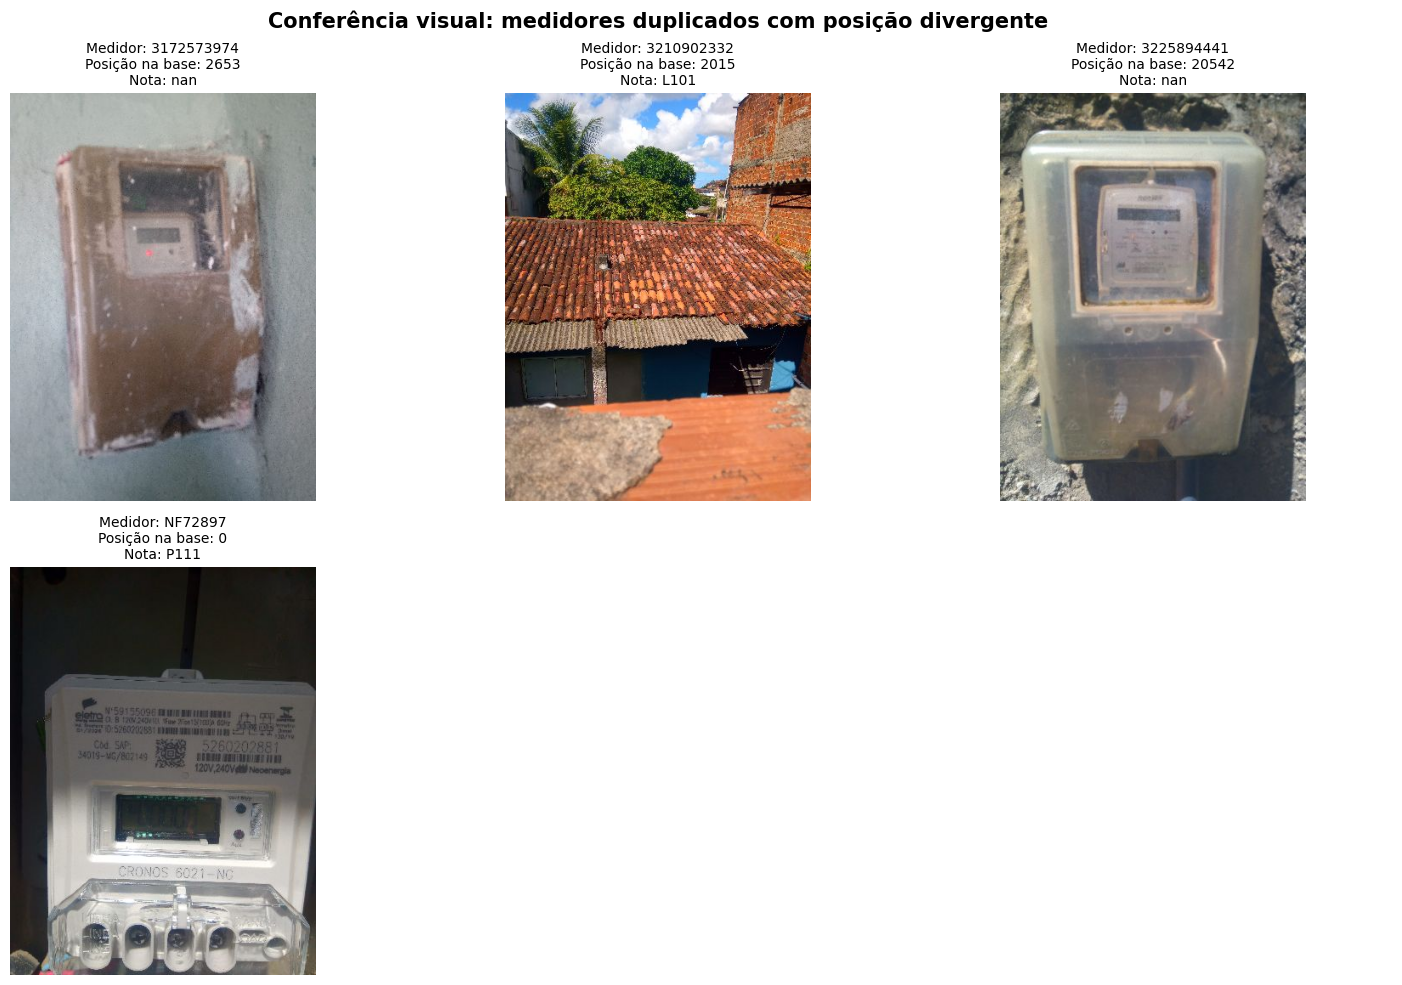

In [9]:
# Analisando as fotos das linhas duplicadas
PASTAS_IMAGENS = [
    "../data/meter_images/PSP_EXTRATLEITIMPL_030726_0121",
    "../data/meter_images/PSP_EXTRATLEITIMPL_200526_0352",
    "../data/meter_images/PSP_EXTRATLEITIMPL_210526_0335",
    "../data/meter_images/PSP_EXTRATLEITIMPL_220526_0408",
]

def encontrar_caminho_foto(nome_foto):
    """Localiza o caminho completo da foto, verificando em qual pasta ela pertence."""
    for pasta in PASTAS_IMAGENS:
        nome_pasta = os.path.basename(pasta)
        if nome_foto.startswith(nome_pasta):
            caminho = os.path.join(pasta, nome_foto)
            if os.path.exists(caminho):
                return caminho
    return None


# 3° caso: medidores duplicados com POSIÇÃO DIFERENTE entre as linhas
duplicados = df[df["Numero do medidor"].duplicated(keep=False)]

grupos_posicao_diferente = duplicados.groupby("Numero do medidor").filter(
    lambda g: g["Posicao do medidor lida"].nunique() > 1
)

# Mantendo só as linhas que têm foto, para conferência visual
casos_com_foto = grupos_posicao_diferente[
    grupos_posicao_diferente["Foto do medidor"].notna()
].sort_values("Numero do medidor").copy()

print(f"Medidores com posição divergente: {grupos_posicao_diferente['Numero do medidor'].nunique()}")
print(f"Linhas com foto disponível para conferência: {len(casos_com_foto)}")


# Plotando as fotos para conferência: a posição na base bate com o display?
n = len(casos_com_foto)
n_cols = 3
n_rows = -(-n // n_cols)  # arredonda pra cima

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten()

for ax, (_, row) in zip(axes, casos_com_foto.iterrows()):
    caminho = encontrar_caminho_foto(row["Foto do medidor"])

    if caminho is None:
        ax.axis("off")
        ax.set_title(f'Foto não encontrada\nMedidor: {row["Numero do medidor"]}', fontsize=9, color="red")
        continue

    img = cv2.cvtColor(cv2.imread(caminho), cv2.COLOR_BGR2RGB)
    ax.imshow(img)
    ax.axis("off")
    ax.set_title(
        f'Medidor: {row["Numero do medidor"]}\n'
        f'Posição na base: {row["Posicao do medidor lida"]}\n'
        f'Nota: {row["Nota de Leitura Atual"]}',
        fontsize=10
    )

# Desliga os eixos que sobrarem no grid
for ax in axes[len(casos_com_foto):]:
    ax.axis("off")

fig.suptitle("Conferência visual: medidores duplicados com posição divergente", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

Analisando melhor as fotos, foi definida a seguinte atitude para os casos de medidor duplicado com posição diferente:

- **Linhas sem foto** → serão **excluídas**, pois não nos ajudam por agora (sem foto não é possível confirmar visualmente qual leitura está correta).
- **Linhas com foto** → serão **mantidas**, para servirem de base na análise exploratória das fotos.

Com isso, seguiremos agora para a **distribuição dos dados**.

Nota de Leitura Atual
T181    2595
P111     685
L101     496
T111     358
B111     123
L131      97
T161      59
M141      56
R111      24
B131      23
M101      20
M121       6
V100       6
B101       3
P101       3
P131       2
T171       1
L121       1
C131       1
T151       1
Name: count, dtype: int64

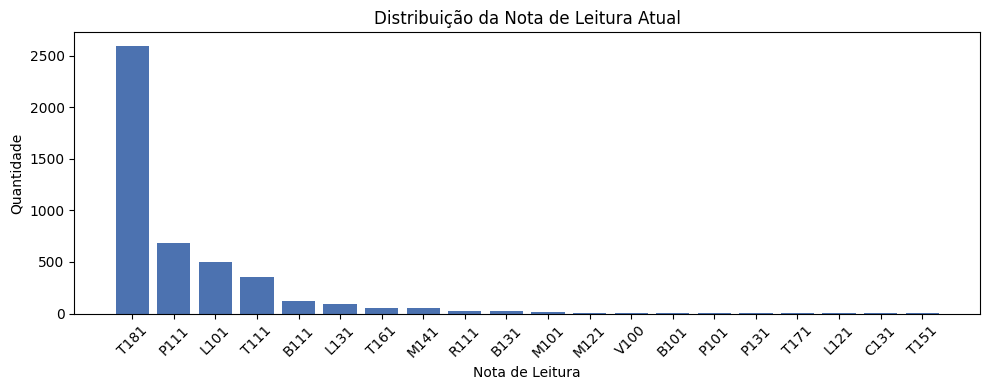

In [56]:
# Distribuição de "Nota de Leitura Atual"
notas = df["Nota de Leitura Atual"].value_counts()
display(notas)

plt.figure(figsize=(10, 4))
plt.bar(notas.index, notas.values, color="#4C72B0")
plt.title("Distribuição da Nota de Leitura Atual")
plt.xlabel("Nota de Leitura")
plt.ylabel("Quantidade")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

`T181` domina amplamente as notas preenchidas (2595 de 4560 não nulas), seguida de `P111` e `L101`. As demais categorias somam poucas ocorrências, indicando forte desbalanceamento entre as notas de leitura.

count     13669.00
mean      43410.84
std       97209.64
min           0.00
25%        3581.00
50%       13577.00
75%       40822.00
max      999999.00
Name: Posicao do medidor lida, dtype: float64

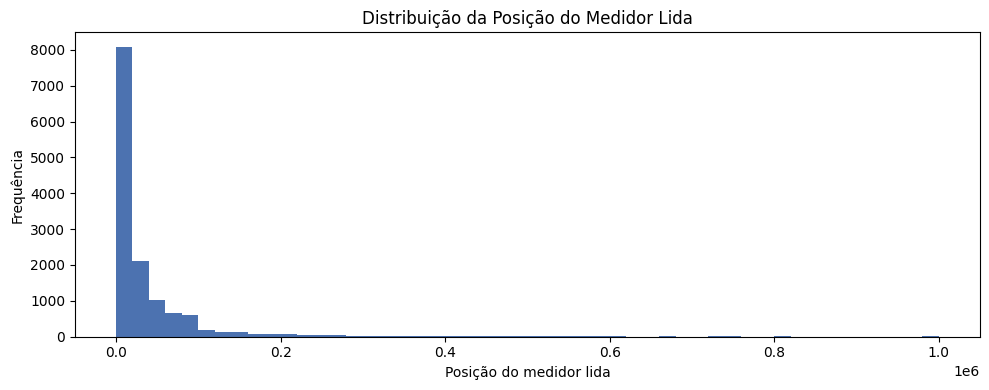

Registros com valor 0: 347
Registros com valor 999999 (possível sentinela): 15


In [57]:
# Distribuição de "Posicao do medidor lida"
display(df["Posicao do medidor lida"].describe().round(2))

plt.figure(figsize=(10, 4))
plt.hist(df["Posicao do medidor lida"], bins=50, color="#4C72B0")
plt.title("Distribuição da Posição do Medidor Lida")
plt.xlabel("Posição do medidor lida")
plt.ylabel("Frequência")
plt.tight_layout()
plt.show()

# Possíveis valores sentinela/outliers
print("Registros com valor 0:", (df["Posicao do medidor lida"] == 0).sum())
print("Registros com valor 999999 (possível sentinela):", (df["Posicao do medidor lida"] == 999999).sum())

A distribuição é bastante assimétrica à direita (mediana ~13.577 vs. média ~43.411), com uma cauda longa até o máximo teórico de leitura. Há 347 registros com posição igual a 0 e 15 registros com valor 999999, que parecem ser valores sentinela/erro.

In [58]:
# analisando esses casos mais detalhadamente
casos_0 = df[
    (df["Posicao do medidor lida"] == 0) &
    (df["Foto do medidor"].notna())
].head(3)

casos_999999 = df[
    (df["Posicao do medidor lida"] == 999999) &
    (df["Foto do medidor"].notna())
].head(3)

casos = pd.concat([casos_0, casos_999999])
casos

,Numero do medidor,Posicao do medidor lida,Nota de Leitura Atual,Foto do medidor
33,6252150569/70017946,0,T111,PSP_EXTRATLEITIMPL_030726_0121_20000000010152996068_000.jpg
129,50818110,0,L101,PSP_EXTRATLEITIMPL_030726_0121_20000000017153016513_000.jpg
217,3242349503/3232901445,0,NaN,PSP_EXTRATLEITIMPL_030726_0121_20000000009352990542_000.jpg
2994,6252251110,999999,NaN,PSP_EXTRATLEITIMPL_030726_0121_20000000011702994327_000.jpg
3010,6252265870/3201066998,999999,NaN,PSP_EXTRATLEITIMPL_030726_0121_20000000002953009342_000.jpg
3471,6252224414/6252260402,999999,T181,PSP_EXTRATLEITIMPL_030726_0121_20000000008552981803_000.jpg


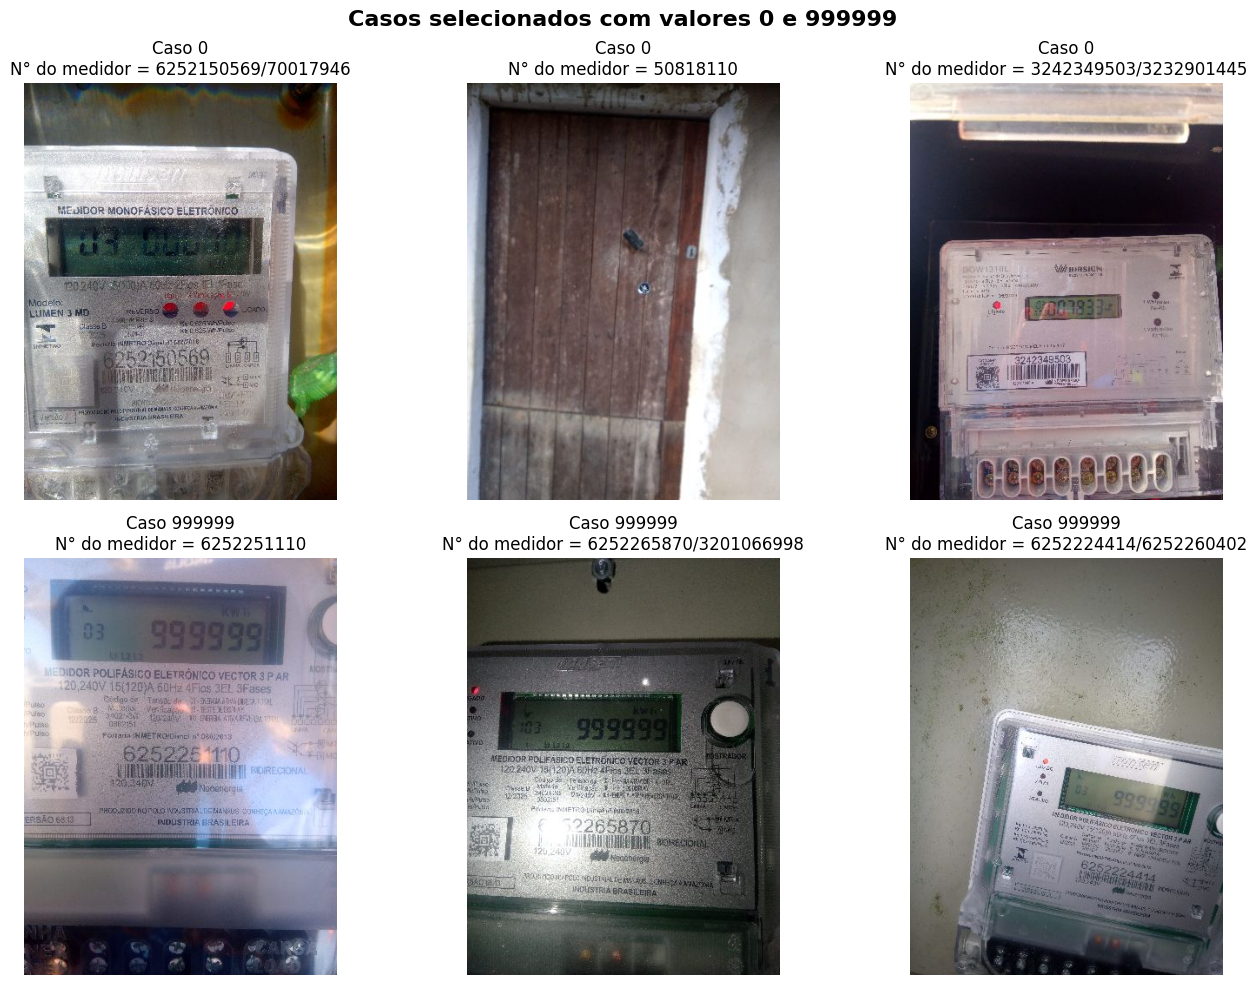

In [59]:
# Analisando as imagens dos casos selecionados
pasta_imagens = "../data/meter_images/PSP_EXTRATLEITIMPL_030726_0121"

fig, axes = plt.subplots(2, 3, figsize=(14, 10))
for ax, (_, row) in zip(axes.flat, casos.iterrows()):

    caminho = os.path.join(
        pasta_imagens,
        row["Foto do medidor"]
    )

    imagem = cv2.imread(caminho)
    imagem = cv2.cvtColor(imagem, cv2.COLOR_BGR2RGB)

    ax.imshow(imagem)
    ax.axis("off")

    ax.set_title(
        f'Caso {row["Posicao do medidor lida"]}\n'
        f'N° do medidor = {row["Numero do medidor"]}',
        fontsize=12
    )

fig.suptitle("Casos selecionados com valores 0 e 999999", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

Olhando as fotos com mais cuidado, os dois grupos têm explicações diferentes:

- **Casos "0"**: ainda é difícil afirmar com certeza a causa. A hipótese mais provável é que o valor 0 seja usado quando **não foi possível identificar/ler o valor do medidor** na foto (foto ilegível, ângulo errado, ou até foto de outro objeto, como visto no caso da porta). Ou seja, aparenta ser um placeholder de falha de leitura, não um valor real.
- **Casos "999999"**: aqui a situação é diferente e mais conclusiva. O valor **realmente existe no display do medidor**. Ou seja, existem medidores com leituras extremamente altas (no limite do display), e não um erro de captura.

**Conclusão parcial:** os casos "0" seguem sendo tratados como suspeitos/possível falha de leitura, enquanto os casos "999999" parecem refletir uma condição real do medidor.

- **Tópico 2 -** Correspondência entre os `CSVs` e as imagens em disco

In [60]:
# Comparando nomes de arquivo citados no CSV com os arquivos existentes em disco
image_paths = glob.glob('../data/meter_images/*/*.jpg')
print("Total de imagens em disco:", len(image_paths))

disk_names = set(os.path.basename(p) for p in image_paths)
csv_names = set(df["Foto do medidor"].dropna())

print("Nomes de imagem citados no CSV:", len(csv_names))
print("Citados no CSV e presentes em disco:", len(csv_names & disk_names))
print("Citados no CSV mas AUSENTES em disco:", len(csv_names - disk_names))
print("Presentes em disco mas NAO citados no CSV (orfãs):", len(disk_names - csv_names))

Total de imagens em disco: 12340
Nomes de imagem citados no CSV: 11474
Citados no CSV e presentes em disco: 11474
Citados no CSV mas AUSENTES em disco: 0
Presentes em disco mas NAO citados no CSV (orfãs): 866


Todas as imagens citadas no CSV (11.474) existem em disco — não há referências quebradas. Por outro lado, das 12.340 imagens em disco, 866 não são citadas em nenhum CSV (imagens "órfãs"), o que sugere leituras feitas que não geraram registro na planilha, ou fotos extras/descartadas pelos leituristas.

- **Tópico 3 -** Análise exploratória das imagens dos medidores

In [61]:
# Verificando dimensões e tamanho de arquivo das imagens por pasta de extração
folders = sorted(glob.glob('../data/meter_images/*'))

for folder in folders:
    imgs = glob.glob(os.path.join(folder, '*.jpg'))[:100]
    dims = set()
    file_sizes_kb = []
    for p in imgs:
        img = cv2.imread(p)
        dims.add(img.shape[:2])  # (altura, largura)
        file_sizes_kb.append(os.path.getsize(p) / 1024)

    print(f"{os.path.basename(folder)}: {len(glob.glob(os.path.join(folder, '*.jpg')))} imagens")
    print(f"  Dimensões (altura, largura) na amostra: {dims}")
    print(f"  Tamanho de arquivo (KB) - min/media/max: {min(file_sizes_kb):.1f} / {np.mean(file_sizes_kb):.1f} / {max(file_sizes_kb):.1f}")
    print()

PSP_EXTRATLEITIMPL_030726_0121: 2992 imagens
  Dimensões (altura, largura) na amostra: {(480, 360)}
  Tamanho de arquivo (KB) - min/media/max: 5.8 / 23.5 / 45.7

PSP_EXTRATLEITIMPL_200526_0352: 3185 imagens
  Dimensões (altura, largura) na amostra: {(480, 360)}
  Tamanho de arquivo (KB) - min/media/max: 8.5 / 24.5 / 46.7

PSP_EXTRATLEITIMPL_210526_0335: 3100 imagens
  Dimensões (altura, largura) na amostra: {(480, 360)}
  Tamanho de arquivo (KB) - min/media/max: 5.9 / 23.8 / 52.3

PSP_EXTRATLEITIMPL_220526_0408: 3063 imagens
  Dimensões (altura, largura) na amostra: {(480, 360)}
  Tamanho de arquivo (KB) - min/media/max: 1.3 / 25.5 / 58.7



Todas as pastas seguem o mesmo padrão: imagens de 480x360 pixels (altura x largura), com tamanho de arquivo pequeno (na casa de dezenas de KB). Isso indica um pipeline de captura padronizado entre as 4 extrações. Vale visualizar uma amostra das imagens para inspecionar qualidade, enquadramento e legibilidade do display do medidor.

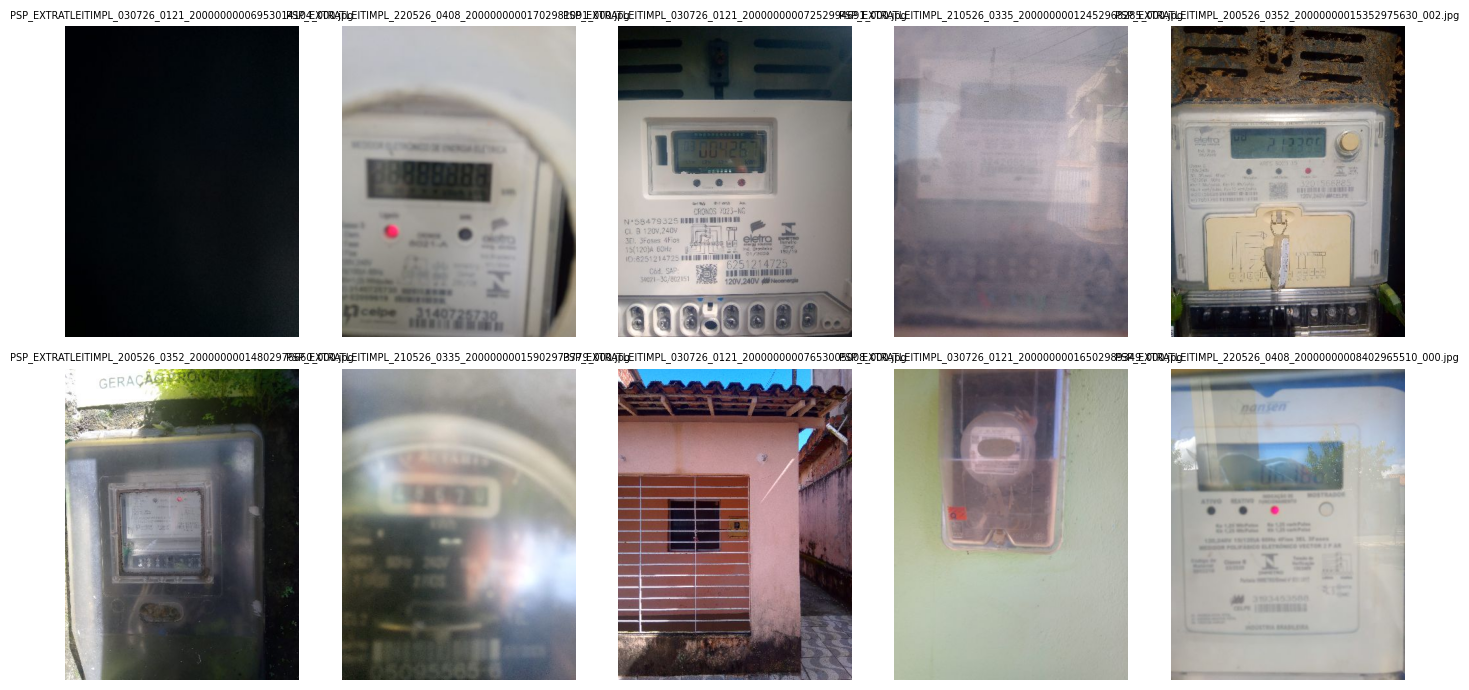

In [69]:
# Visualizando uma amostra aleatória de imagens
rng = np.random.default_rng(42)
sample_paths = rng.choice(image_paths, size=10, replace=False)

fig, axes = plt.subplots(2, 5, figsize=(14, 7))
for ax, path in zip(axes.flat, sample_paths):
    img = cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB)
    ax.imshow(img)
    ax.set_title(os.path.basename(path), fontsize=7)
    ax.axis("off")

plt.tight_layout()
plt.show()

A ideia agora, não será mais olhar fotos isoladas, e sim medir a qualidade de **todas as imagens de cada pasta** e ver qual condição predomina (maioria borrada, maioria escura, etc.), para entender se algum lote de extração tem problema sistemático de qualidade que pode atrapalhar a leitura/OCR do medidor.

In [63]:
# Funções de métricas de qualidade de imagem

def estimar_ruido(gray):
    """Estimativa rápida de ruído (método de Immerkaer, 1996): quanto maior, mais ruidosa a imagem."""
    H, W = gray.shape
    M = np.array([[1, -2, 1],
                  [-2, 4, -2],
                  [1, -2, 1]])
    conv = cv2.filter2D(gray.astype(np.float64), -1, M)
    sigma = np.sum(np.abs(conv))
    sigma = sigma * np.sqrt(0.5 * np.pi) / (6 * (W - 2) * (H - 2))
    return sigma


def metricas_qualidade(caminho_imagem):
    """Calcula nitidez, claridade, contraste e ruído de uma imagem."""
    img = cv2.imread(caminho_imagem)
    if img is None:
        return None
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    nitidez = cv2.Laplacian(gray, cv2.CV_64F).var()  # quanto maior, mais nítida (foco)
    claridade = gray.mean()                          # brilho médio (0-255)
    contraste = gray.std()                            # dispersão de intensidade
    ruido = estimar_ruido(gray)                        # quanto maior, mais ruidosa

    return {
        "nitidez": nitidez,
        "claridade": claridade,
        "contraste": contraste,
        "ruido": ruido,
    }

In [64]:
# Calculando as métricas para TODAS as imagens de cada pasta (não apenas uma amostra)
registros = []

for folder in folders:
    nome_pasta = os.path.basename(folder)
    imgs = glob.glob(os.path.join(folder, '*.jpg'))
    print(f"Processando pasta \'{nome_pasta}\': {len(imgs)} imagens...")

    for caminho in imgs:
        m = metricas_qualidade(caminho)
        if m is None:
            continue
        m["pasta"] = nome_pasta
        m["arquivo"] = os.path.basename(caminho)
        registros.append(m)

df_qualidade = pd.DataFrame(registros)
print(f"\nTotal de imagens processadas: {len(df_qualidade)}")
df_qualidade.head()

Processando pasta 'PSP_EXTRATLEITIMPL_030726_0121': 2992 imagens...
Processando pasta 'PSP_EXTRATLEITIMPL_200526_0352': 3185 imagens...
Processando pasta 'PSP_EXTRATLEITIMPL_210526_0335': 3100 imagens...
Processando pasta 'PSP_EXTRATLEITIMPL_220526_0408': 3063 imagens...

Total de imagens processadas: 12340


,nitidez,claridade,contraste,ruido,pasta,arquivo
0,56.884551,166.657054,45.436477,0.465537,PSP_EXTRATLEITIMPL_030726_0121,PSP_EXTRATLEITIMPL_030726_0121_00000000000211765824_000.jpg
1,469.678064,147.505249,44.574040,1.489046,PSP_EXTRATLEITIMPL_030726_0121,PSP_EXTRATLEITIMPL_030726_0121_00000000000211770854_000.jpg
2,59.682551,124.450990,40.980261,0.493472,PSP_EXTRATLEITIMPL_030726_0121,PSP_EXTRATLEITIMPL_030726_0121_00000000000211772822_000.jpg
3,261.990760,126.986973,42.748290,1.190557,PSP_EXTRATLEITIMPL_030726_0121,PSP_EXTRATLEITIMPL_030726_0121_00000000000211776732_000.jpg
4,672.827542,151.616047,41.588574,2.004693,PSP_EXTRATLEITIMPL_030726_0121,PSP_EXTRATLEITIMPL_030726_0121_00000000000211778687_000.jpg


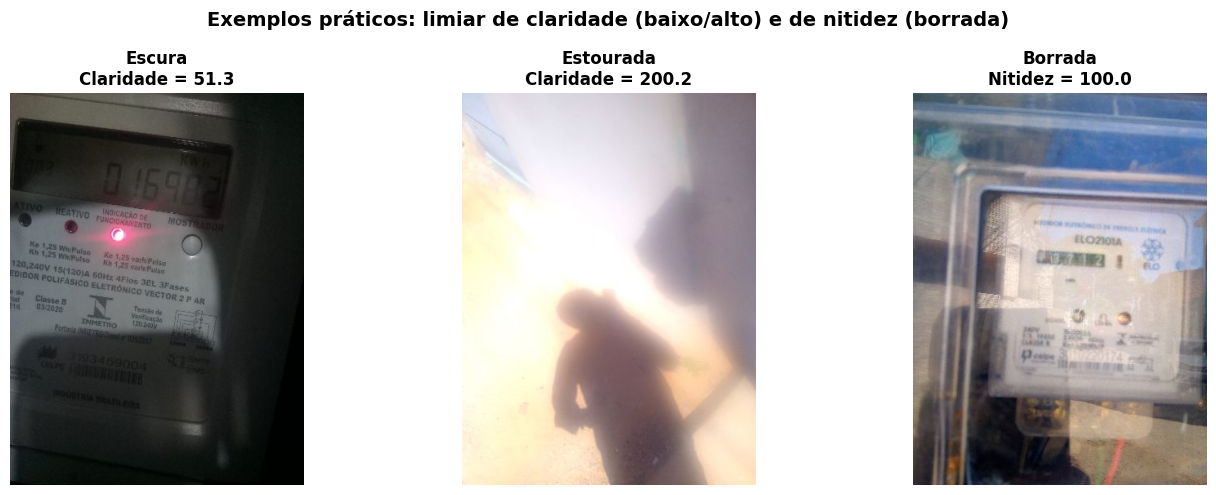

In [ ]:
# Definição de limiares para classificação de imagens com base em métricas de qualidade

LIMIAR_BORRADA = 100     
LIMIAR_ESCURA = 60       
LIMIAR_ESTOURADA = 200 


PASTA_IMAGENS_BASE = "../data/meter_images"
MARGEM_CLARIDADE = 10  # faixa ao redor dos limiares de claridade

# imagem perto do limiar de escura (LIMIAR_ESCURA)
candidatas_escura = df_qualidade[
    (df_qualidade["claridade"] >= LIMIAR_ESCURA - MARGEM_CLARIDADE) &
    (df_qualidade["claridade"] <= LIMIAR_ESCURA + MARGEM_CLARIDADE)
]
exemplo_escura = candidatas_escura.sample(1).iloc[0]

# imagem perto do limiar de estourada (LIMIAR_ESTOURADA)
candidatas_estourada = df_qualidade[
    (df_qualidade["claridade"] >= LIMIAR_ESTOURADA - MARGEM_CLARIDADE) &
    (df_qualidade["claridade"] <= LIMIAR_ESTOURADA + MARGEM_CLARIDADE)
]
exemplo_estourada = candidatas_estourada.sample(1).iloc[0]

# imagem perto do limiar de borrada (LIMIAR_BORRADA)
candidatas_borrada = df_qualidade[
    (df_qualidade["nitidez"] >= LIMIAR_BORRADA - 30) &
    (df_qualidade["nitidez"] <= LIMIAR_BORRADA + 30)
]
exemplo_borrada = candidatas_borrada.sample(1).iloc[0]

exemplos = [exemplo_escura, exemplo_estourada, exemplo_borrada]
titulos_metrica = [
    lambda r: f'Escura\nClaridade = {r["claridade"]:.1f}',
    lambda r: f'Estourada\nClaridade = {r["claridade"]:.1f}',
    lambda r: f'Borrada\nNitidez = {r["nitidez"]:.1f}',
]

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for ax, row, titulo_fn in zip(axes, exemplos, titulos_metrica):
    caminho = os.path.join(PASTA_IMAGENS_BASE, row["pasta"], row["arquivo"])
    img = cv2.cvtColor(cv2.imread(caminho), cv2.COLOR_BGR2RGB)
    ax.imshow(img)
    ax.axis("off")
    ax.set_title(titulo_fn(row), fontsize=12, fontweight="bold")

fig.suptitle("Exemplos práticos: limiar de claridade (baixo/alto) e de nitidez (borrada)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [94]:
# Classificando cada imagem com base em limiares de referência
df_qualidade["status_nitidez"] = np.where(df_qualidade["nitidez"] < LIMIAR_BORRADA, "Borrada", "Nítida")
df_qualidade["status_claridade"] = np.select(
    [df_qualidade["claridade"] < LIMIAR_ESCURA, df_qualidade["claridade"] > LIMIAR_ESTOURADA],
    ["Escura", "Estourada"],
    default="Adequada"
)

df_qualidade.head()

,nitidez,claridade,contraste,ruido,pasta,arquivo,status_nitidez,status_claridade
0,56.884551,166.657054,45.436477,0.465537,PSP_EXTRATLEITIMPL_030726_0121,PSP_EXTRATLEITIMPL_030726_0121_00000000000211765824_000.jpg,Borrada,Adequada
1,469.678064,147.505249,44.574040,1.489046,PSP_EXTRATLEITIMPL_030726_0121,PSP_EXTRATLEITIMPL_030726_0121_00000000000211770854_000.jpg,Nítida,Adequada
2,59.682551,124.450990,40.980261,0.493472,PSP_EXTRATLEITIMPL_030726_0121,PSP_EXTRATLEITIMPL_030726_0121_00000000000211772822_000.jpg,Borrada,Adequada
3,261.990760,126.986973,42.748290,1.190557,PSP_EXTRATLEITIMPL_030726_0121,PSP_EXTRATLEITIMPL_030726_0121_00000000000211776732_000.jpg,Nítida,Adequada
4,672.827542,151.616047,41.588574,2.004693,PSP_EXTRATLEITIMPL_030726_0121,PSP_EXTRATLEITIMPL_030726_0121_00000000000211778687_000.jpg,Nítida,Adequada


In [66]:
# Estatísticas agregadas por pasta (média, mediana e desvio padrão de cada métrica)
resumo_metricas = (
    df_qualidade
    .groupby("pasta")[["nitidez", "claridade", "contraste", "ruido"]]
    .agg(["mean", "median", "std"])
    .round(2)
)
resumo_metricas

nitidez                  claridade          \
                                  mean  median      std      mean  median   
pasta                                                                       
PSP_EXTRATLEITIMPL_030726_0121  689.41  293.71  1217.99    124.03  126.11   
PSP_EXTRATLEITIMPL_200526_0352  660.62  278.24  1089.27    122.36  126.05   
PSP_EXTRATLEITIMPL_210526_0335  673.56  271.64  1153.98    120.91  124.47   
PSP_EXTRATLEITIMPL_220526_0408  684.45  280.75  1360.37    122.18  126.02   

                                      contraste               ruido         \
                                  std      mean median    std  mean median   
pasta                                                                        
PSP_EXTRATLEITIMPL_030726_0121  26.36     52.49  53.50  13.64  1.80   1.13   
PSP_EXTRATLEITIMPL_200526_0352  29.54     51.74  52.53  14.17  1.73   1.10   
PSP_EXTRATLEITIMPL_210526_0335  29.42     52.50  53.79  14.24  1.77   1.11   
PSP_EXTRATLEITIMPL_220526_0408  29.80     51.85  53.15  14.39  1.77   1.09   

                                      
                                 std  
pasta                                 
PSP_EXTRATLEITIMPL_030726_0121  2.16  
PSP_EXTRATLEITIMPL_200526_0352  1.95  
PSP_EXTRATLEITIMPL_210526_0335  2.04  
PSP_EXTRATLEITIMPL_220526_0408  2.24

In [67]:
# Qual condição predomina (maioria) em cada pasta
resumo_status = df_qualidade.groupby("pasta").agg(
    total_imagens=("arquivo", "count"),
    pct_borrada=("status_nitidez", lambda s: (s == "Borrada").mean() * 100),
    pct_escura=("status_claridade", lambda s: (s == "Escura").mean() * 100),
    pct_estourada=("status_claridade", lambda s: (s == "Estourada").mean() * 100),
    pct_adequada=("status_claridade", lambda s: (s == "Adequada").mean() * 100),
).round(1)

resumo_status["maioria_nitidez"] = np.where(
    resumo_status["pct_borrada"] > 50, "Maioria BORRADA", "Maioria NÍTIDA"
)
resumo_status["maioria_claridade"] = (
    resumo_status[["pct_escura", "pct_estourada", "pct_adequada"]]
    .idxmax(axis=1)
    .map({
        "pct_escura": "Maioria ESCURA",
        "pct_estourada": "Maioria ESTOURADA",
        "pct_adequada": "Maioria ADEQUADA",
    })
)

resumo_status

,total_imagens,pct_borrada,pct_escura,pct_estourada,pct_adequada,maioria_nitidez,maioria_claridade
pasta,,,,,,,
PSP_EXTRATLEITIMPL_030726_0121,2992,32.1,2.2,0.0,97.8,Maioria NÍTIDA,Maioria ADEQUADA
PSP_EXTRATLEITIMPL_200526_0352,3185,33.4,4.4,0.0,95.6,Maioria NÍTIDA,Maioria ADEQUADA
PSP_EXTRATLEITIMPL_210526_0335,3100,32.5,4.4,0.1,95.5,Maioria NÍTIDA,Maioria ADEQUADA
PSP_EXTRATLEITIMPL_220526_0408,3063,33.1,4.0,0.0,96.0,Maioria NÍTIDA,Maioria ADEQUADA


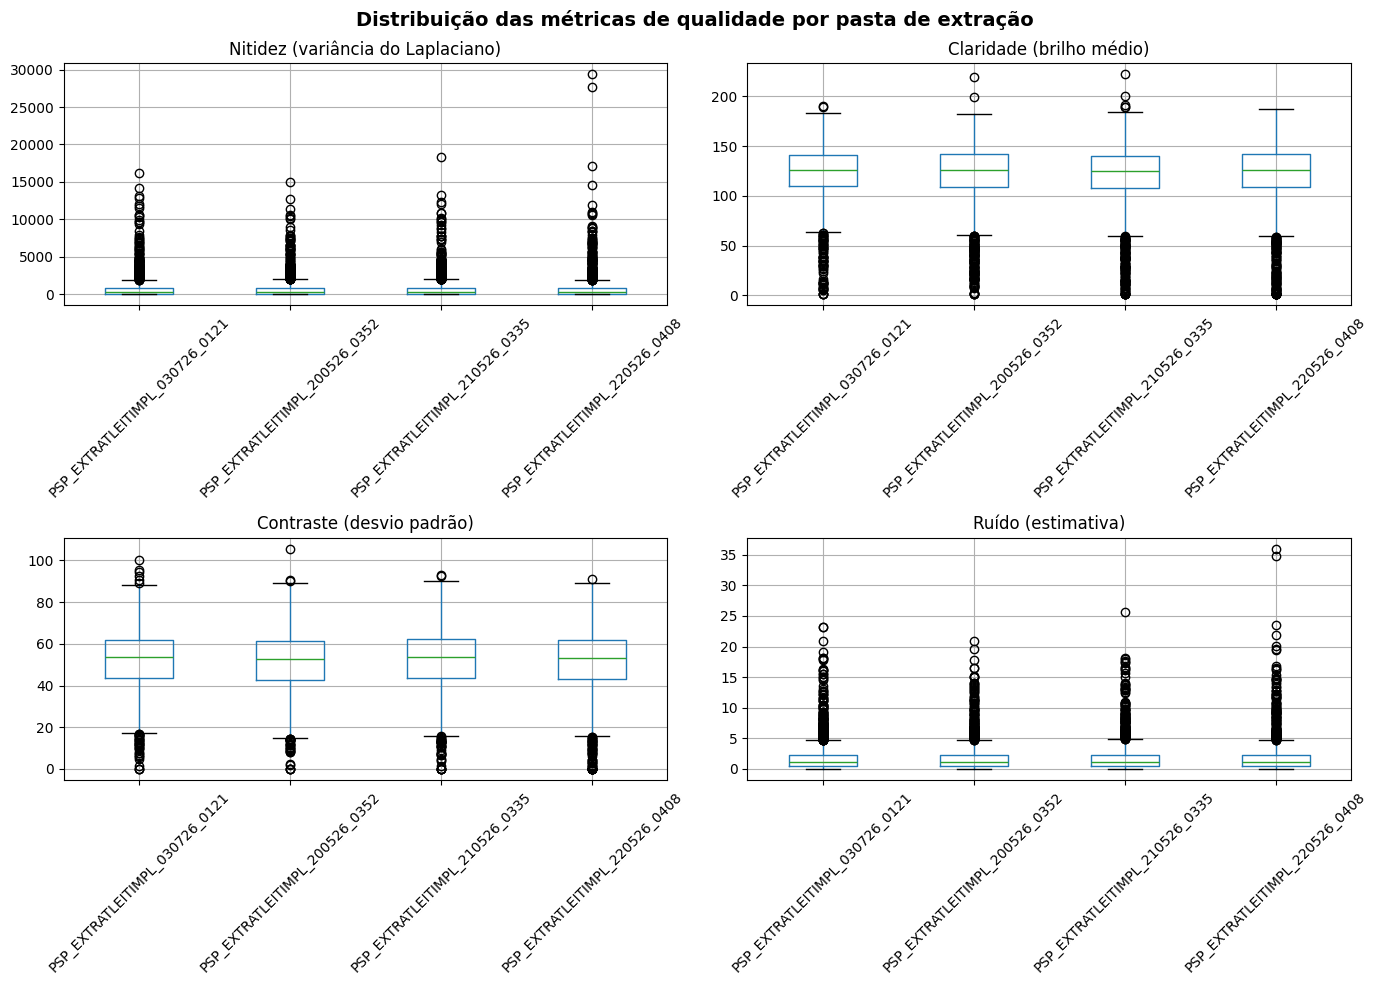

In [68]:
# Distribuição completa das métricas por pasta (todas as imagens, não só uma amostra)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

metricas_titulos = [
    ("nitidez", "Nitidez (variância do Laplaciano)"),
    ("claridade", "Claridade (brilho médio)"),
    ("contraste", "Contraste (desvio padrão)"),
    ("ruido", "Ruído (estimativa)"),
]

for ax, (metrica, titulo) in zip(axes.flat, metricas_titulos):
    df_qualidade.boxplot(column=metrica, by="pasta", ax=ax, rot=45)
    ax.set_title(titulo)
    ax.set_xlabel("")

plt.suptitle("Distribuição das métricas de qualidade por pasta de extração", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

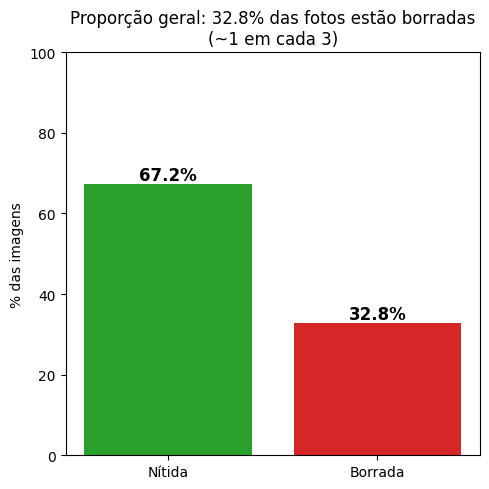

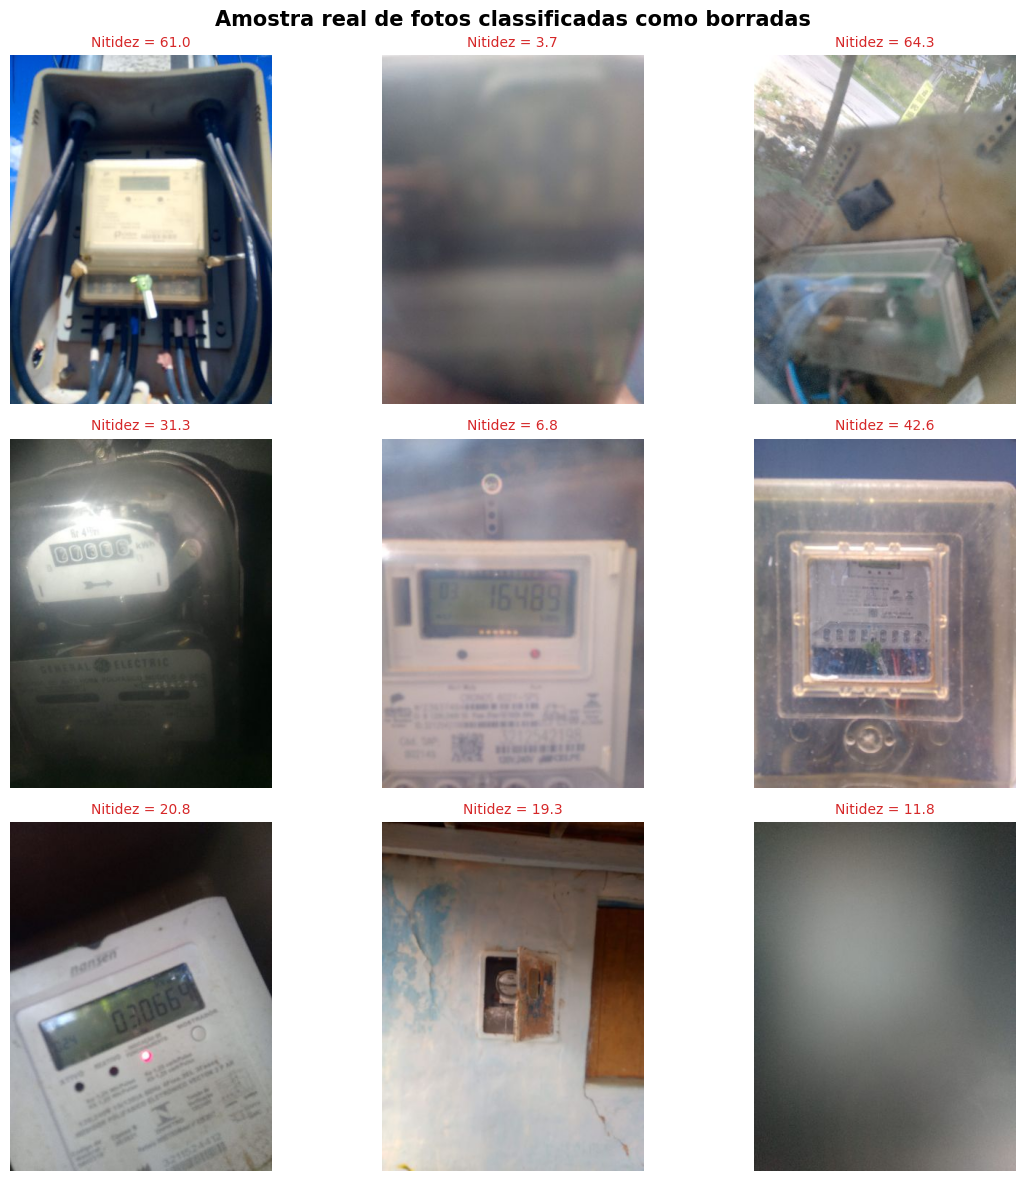

In [97]:
# 1) Gráfico mostrando a proporção geral de imagens borradas vs. nítidas
PASTA_IMAGENS_BASE = "../data/meter_images"

proporcao_geral = df_qualidade["status_nitidez"].value_counts(normalize=True) * 100

fig, ax = plt.subplots(figsize=(5, 5))
cores = {"Borrada": "#d62728", "Nítida": "#2ca02c"}
ax.bar(proporcao_geral.index, proporcao_geral.values,
       color=[cores[s] for s in proporcao_geral.index])

for i, v in enumerate(proporcao_geral.values):
    ax.text(i, v + 1, f"{v:.1f}%", ha="center", fontsize=12, fontweight="bold")

ax.set_ylabel("% das imagens")
ax.set_ylim(0, 100)
ax.set_title(f"Proporção geral: {proporcao_geral.get('Borrada', 0):.1f}% das fotos estão borradas\n(~1 em cada {round(100/proporcao_geral.get('Borrada', 1))})")
plt.tight_layout()
plt.show()


# 2) Mosaico com uma amostra real de fotos borradas, pra mostrar na prática o que isso significa
amostra_borradas = df_qualidade[df_qualidade["status_nitidez"] == "Borrada"].sample(n=9, random_state=42)

fig, axes = plt.subplots(3, 3, figsize=(12, 12))
for ax, (_, row) in zip(axes.flat, amostra_borradas.iterrows()):
    caminho = os.path.join(PASTA_IMAGENS_BASE, row["pasta"], row["arquivo"])
    img = cv2.cvtColor(cv2.imread(caminho), cv2.COLOR_BGR2RGB)
    ax.imshow(img)
    ax.axis("off")
    ax.set_title(f'Nitidez = {row["nitidez"]:.1f}', fontsize=10, color="#d62728")

fig.suptitle("Amostra real de fotos classificadas como borradas", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

#### Resumo da EDA de qualidade das imagens (por pasta)

- **Volume**: as 4 pastas de extração somam **~12.340 imagens** processadas (2.992 / 3.185 / 3.100 / 3.063).

- **Claridade e contraste não são gargalo**: média de claridade entre 120 e 124 (mediana 124-126), desvio baixo (26-30) e praticamente idêntica nas 4 pastas. Entre **95,5% e 97,8%** das imagens são classificadas como "Adequada"; escuras representam só 2,2% a 4,4%; estouradas são quase inexistentes (≤0,1%). Contraste também estável (~51-53) em todas as pastas.

- **Nitidez é o ponto de atenção**: distribuição fortemente assimétrica. Mediana (~270-295) bem abaixo da média (~660-690), com cauda de outliers chegando perto de 30.000 (imagens excepcionalmente nítidas puxando a média). Ainda assim, **32% a 33% das imagens de cada pasta são "Borrada"** (abaixo do limiar de nitidez de 100), ou seja, a cada 3 imagens 1 geralmente é borrada.

- **Ruído**: mesmo padrão de assimetria da nitidez (mediana ~1,1 vs. média ~1,7-1,8, outliers até ~35), mas a maioria das imagens tem ruído baixo. Não parece ser o principal problema.

- **Consistência entre pastas**: os perfis de qualidade das 4 pastas (`030726_0121`, `200526_0352`, `210526_0335`, `220526_0408`) são praticamente idênticos. Nenhuma pasta se destaca como pior. Isso indica que a taxa de ~32% de imagens borradas é uma **característica sistemática do processo de captura** (app/câmera do leiturista, condição em campo), e não um problema pontual de um lote específico.

**Recomendação**: usar o filtro de nitidez (Laplaciano < 100) para sinalizar as imagens borradas como candidatas a nova captura ou a pré-processamento (sharpening) antes de qualquer etapa de OCR/leitura automática dos dígitos. Claridade e contraste podem ficar fora dessa etapa, já que mais de 95% das imagens já estão em condição adequada.